<h1 style="color: #25a890; font-size: 2.2em; margin-bottom: 5px; font-weight: 700;">Customer Segmentation | EDA & Preprocessing</h1>

<p style="margin: 3px 0; font-size: 1.1em; font-weight: 600;">NOVA IMS <span style="font-weight: 300;">| Machine Learning 2</span></p>
<p style="margin: 3px 0; font-size: 0.95em;"><strong">Professors</strong> Fernando Bação & Ivo Bernardo</p>


<br>
<table style="width: 100%; border-collapse: collapse; font-size: 1em;">
    <tr>
        <td style="padding: 4px 0; font-weight: 500;">Diogo Gonçalves</td>
        <td style="padding: 4px 0; text-align: right; font-family: monospace;">(20241817)</td>
    </tr>
    <tr>
        <td style="padding: 4px 0; font-weight: 500;">Gustavo Franco</td>
        <td style="padding: 4px 0; text-align: right; font-family: monospace;">(20241806)</td>
    </tr>
    <tr>
        <td style="padding: 4px 0; font-weight: 500;">Simão Costa</td>
        <td style="padding: 4px 0; text-align: right; font-family: monospace;">(20241772)</td>
    </tr>


    


# DON'T FORGET THE INDEX

<h2 style="color: #25a890; margin-bottom: 5px; font-weight: 700;">Library Imports</h2>

In [320]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

<h2 style="color: #25a890; margin-bottom: 5px; font-weight: 700;">Data Import</h2>

In [321]:
pd.set_option('display.max_columns', None) # option to see all columns

cust_info = pd.read_csv('customer_info.csv', index_col=0)

cust_basket = pd.read_csv('customer_basket.csv', index_col=0)

In [322]:
cust_info.head()

,customer_name,customer_gender,customer_birthdate,kids_home,teens_home,number_complaints,distinct_stores_visited,lifetime_spend_groceries,lifetime_spend_electronics,typical_hour,lifetime_spend_vegetables,lifetime_spend_nonalcohol_drinks,lifetime_spend_alcohol_drinks,lifetime_spend_meat,lifetime_spend_fish,lifetime_spend_hygiene,lifetime_spend_videogames,lifetime_spend_petfood,lifetime_total_distinct_products,percentage_of_products_bought_promotion,year_first_transaction,loyalty_card_number,latitude,longitude
customer_id,,,,,,,,,,,,,,,,,,,,,,,,
3,Bsc. Crystal Kitchens,female,02/12/1970 01:36 PM,1.0,1.0,1.0,3.0,11731.0,4553.0,NaN,373.0,323.0,177.0,28.0,213.0,552.0,256.0,384.0,189.0,0.631599,2020.0,1.0,38.794428,-9.215739
4,Bsc. Glenda Bauman,female,11/13/1975 06:58 PM,1.0,0.0,0.0,2.0,13694.0,963.0,NaN,2012.0,533.0,95.0,43.0,15.0,1880.0,333.0,665.0,130.0,0.149890,2013.0,1.0,38.751711,-9.179611
5,Msc. Antonio Campbell,male,09/10/1971 10:07 AM,0.0,0.0,NaN,2.0,12407.0,0.0,11.0,555.0,101.0,118.0,1265.0,273.0,507.0,101.0,222.0,81.0,0.069126,2005.0,NaN,38.780678,-9.160656
7,John Kelling,male,10/23/1982 11:20 AM,0.0,0.0,2.0,1.0,7493.0,1105.0,18.0,84.0,757.0,1133.0,972.0,1083.0,485.0,1656.0,184.0,92.0,0.253609,2021.0,1.0,38.739548,-9.148679
8,Arthur Dematteo,male,08/04/1969 10:22 PM,0.0,0.0,3.0,1.0,9187.0,10841.0,17.0,380.0,592.0,718.0,1068.0,1015.0,297.0,1258.0,441.0,6.0,0.186569,2021.0,1.0,38.733071,-9.188188


In [323]:
cust_info.info()

<class 'pandas.core.frame.DataFrame'>
Index: 33038 entries, 3 to 40000
Data columns (total 24 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   customer_name                            33038 non-null  object 
 1   customer_gender                          33038 non-null  object 
 2   customer_birthdate                       32873 non-null  object 
 3   kids_home                                32708 non-null  float64
 4   teens_home                               32708 non-null  float64
 5   number_complaints                        32377 non-null  float64
 6   distinct_stores_visited                  32708 non-null  float64
 7   lifetime_spend_groceries                 33038 non-null  float64
 8   lifetime_spend_electronics               32377 non-null  float64
 9   typical_hour                             32377 non-null  float64
 10  lifetime_spend_vegetables                32377 non-

In [324]:
cust_info.describe()

,kids_home,teens_home,number_complaints,distinct_stores_visited,lifetime_spend_groceries,lifetime_spend_electronics,typical_hour,lifetime_spend_vegetables,lifetime_spend_nonalcohol_drinks,lifetime_spend_alcohol_drinks,lifetime_spend_meat,lifetime_spend_fish,lifetime_spend_hygiene,lifetime_spend_videogames,lifetime_spend_petfood,lifetime_total_distinct_products,percentage_of_products_bought_promotion,year_first_transaction,loyalty_card_number,latitude,longitude
count,32708.000000,32708.000000,32377.000000,32708.000000,33038.000000,32377.000000,32377.000000,32377.000000,33038.000000,32708.000000,32377.000000,32047.000000,32708.00000,32377.000000,32377.000000,33038.000000,32708.000000,33038.000000,19932.0,33038.000000,33038.000000
mean,1.116118,0.898893,0.930846,3.167941,16306.227798,2763.080088,12.659388,727.223801,464.352776,622.144185,723.721716,608.781228,820.34646,373.900917,336.217099,148.914644,0.318866,2015.311853,1.0,38.749694,-9.154549
std,1.150186,0.962924,0.894658,1.674114,11985.903518,3453.191495,4.854708,654.633087,275.767976,517.744320,483.022782,497.068874,608.31732,460.782042,160.234980,105.922907,0.283638,5.032196,0.0,0.022498,0.028581
min,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,-1.274940,1993.000000,1.0,38.687987,-9.232989
25%,0.000000,0.000000,0.000000,2.000000,8647.000000,579.000000,8.000000,224.000000,241.000000,201.000000,343.000000,171.000000,362.00000,125.000000,225.000000,67.000000,0.122359,2012.000000,1.0,38.734079,-9.173732
50%,1.000000,1.000000,1.000000,3.000000,13002.500000,1470.000000,12.000000,471.000000,421.000000,483.000000,729.000000,511.000000,686.00000,223.000000,327.000000,123.000000,0.239449,2015.000000,1.0,38.748286,-9.156689
75%,1.000000,1.000000,1.000000,4.000000,20807.000000,3745.000000,16.000000,1074.000000,640.000000,891.250000,1010.000000,923.000000,1120.00000,374.000000,435.000000,210.000000,0.469390,2019.000000,1.0,38.765779,-9.139608
max,8.000000,6.000000,7.000000,10.000000,104670.000000,35299.000000,23.000000,3337.000000,2180.000000,3704.000000,3052.000000,3172.000000,3482.00000,3936.000000,1224.000000,600.000000,1.000000,2029.000000,1.0,38.823693,-9.035697


In [325]:
cust_basket.head()

,list_of_goods,customer_id
invoice_id,,
3700630,"['chicken', 'rice', 'pepper', 'whole wheat ric...",12912
10242376,"['low fat yogurt', 'tomatoes', 'pepper', 'aspa...",22853
91550,"['cake', 'tomatoes', 'pancakes', 'iPad', 'fina...",19
3137503,"['cereals', 'megaman zero', 'final fantasy XIX...",10995
7165061,"['rice', 'frozen smoothie', 'black tea', 'tea'...",27807


In [326]:
cust_basket.info()

<class 'pandas.core.frame.DataFrame'>
Index: 100000 entries, 3700630 to 12236507
Data columns (total 2 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   list_of_goods  100000 non-null  object
 1   customer_id    100000 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 2.3+ MB


In [327]:
cust_basket.describe()

,customer_id
count,100000.000000
mean,20034.595410
std,11546.142217
min,3.000000
25%,10026.000000
50%,20018.000000
75%,30047.000000
max,40000.000000


<h2 style="color: #25a890; margin-bottom: 5px; font-weight: 700;">Data Cleaning</h2>

<h3 style="color: #25a890; margin-bottom: 5px; font-weight: 700;">Duplicates</h3>

Checking for duplicates (rows 100% equal) in both datasets.

In [328]:
cust_info.duplicated().sum()

np.int64(0)

In [329]:
cust_basket.duplicated().sum()

np.int64(0)

We found 0 duplicate rows in both datasets.

<h3 style="color: #25a890; margin-bottom: 5px; font-weight: 700;">Variable Consistency</h3>

<h4 style="color: #25a890; margin-bottom: 5px; font-weight: 700;"><code style="color: #25a890;">customer_name</code></h4>

- string
- no missing values
- 495 duplicates (1.5%) - can be true duplicates, as 2 customers might have same names

In [330]:
cust_info['customer_name'].head(10)

customer_id
3     Bsc. Crystal Kitchens
4        Bsc. Glenda Bauman
5     Msc. Antonio Campbell
7              John Kelling
8           Arthur Dematteo
9        Msc. Nadine Garcia
10       Phd. Franklin Alba
11      Bsc. Robert Hansing
12     Phd. Dorothy Pacheco
14      Msc. Arron Burgener
Name: customer_name, dtype: object

In [331]:
variable = 'customer_name'
print("Duplicates: " + str(cust_info[variable].duplicated().sum()))
percentage = cust_info[variable].duplicated().sum() / len(cust_info) * 100
print("Duplicates Percentage: " + percentage.round(2).astype(str) + "%")
print(" ")
print("Missing Values: " + str(cust_info[variable].isnull().sum()))
percentage = cust_info[variable].isnull().sum() / len(cust_info) * 100
print("Missing Values Percentage: " + percentage.round(2).astype(str) + "%")

Duplicates: 495
Duplicates Percentage: 1.5%
 
Missing Values: 0
Missing Values Percentage: 0.0%


<h4 style="color: #25a890; margin-bottom: 5px; font-weight: 700;"><code style="color: #25a890;">customer_gender</code></h4>

- string, of binary nature - female or male
- no missing values
- roughly well distributed between 2 classes

In [332]:
cust_info['customer_gender'].value_counts()

customer_gender
female    16577
male      16461
Name: count, dtype: int64

In [333]:
variable = 'customer_gender'

print("Missing Values:" + str(cust_info[variable].isnull().sum()))
percentage = cust_info[variable].isnull().sum() / len(cust_info) * 100
print("Missing Values Percentage: " + percentage.round(2).astype(str) + "%")

Missing Values:0
Missing Values Percentage: 0.0%


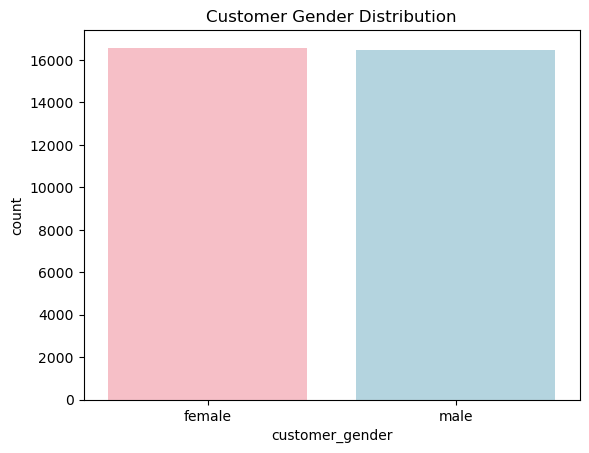

In [334]:
palette = {'male': 'lightblue', 'female': 'lightpink'}

sns.countplot(data=cust_info, x='customer_gender', palette=palette)
plt.title('Customer Gender Distribution')
plt.show()

<h4 style="color: #25a890; margin-bottom: 5px; font-weight: 700;"><code style="color: #25a890;">customer_birthdate</code></h4>

- datetime - year, month, day, hour, minute
- 165 (0,5%) of missing values
- years between 1940 and 2002

<b>Transformations:</b>
- for simplicity in the dataset, we can transform this variable in a <code style="color: #25a890;">age</code> variable.

In [335]:
variable = 'customer_birthdate'
print("Duplicates: " + str(cust_info[variable].duplicated().sum()))
percentage = cust_info[variable].duplicated().sum() / len(cust_info) * 100
print("Duplicates Percentage: " + percentage.round(2).astype(str) + "%")
print(" ")
print("Missing Values: " + str(cust_info[variable].isnull().sum()))
percentage = cust_info[variable].isnull().sum() / len(cust_info) * 100
print("Missing Values Percentage: " + percentage.round(2).astype(str) + "%")

Duplicates: 185
Duplicates Percentage: 0.56%
 
Missing Values: 165
Missing Values Percentage: 0.5%


In [336]:
pd.to_datetime(cust_info['customer_birthdate']).dt.year.describe()

count    32873.000000
mean      1970.879749
std         18.064552
min       1940.000000
25%       1955.000000
50%       1971.000000
75%       1987.000000
max       2002.000000
Name: customer_birthdate, dtype: float64

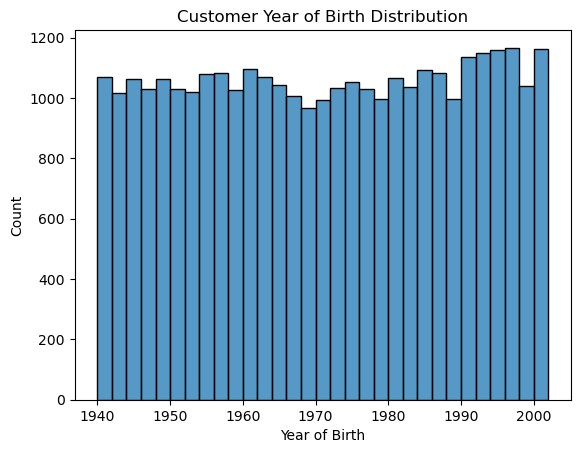

In [337]:
customer_year = pd.to_datetime(cust_info['customer_birthdate']).dt.year

sns.histplot(data=customer_year, palette=palette, bins=31)
plt.title('Customer Year of Birth Distribution')
plt.xlabel('Year of Birth')
plt.ylabel('Count')
plt.show()

In [338]:
cust_info['age'] = 2024 - pd.to_datetime(cust_info['customer_birthdate']).dt.year

In [339]:
variable = 'age'
print("Duplicates: " + str(cust_info[variable].duplicated().sum()))
percentage = cust_info[variable].duplicated().sum() / len(cust_info) * 100
print("Duplicates Percentage: " + percentage.round(2).astype(str) + "%")
print(" ")
print("Missing Values: " + str(cust_info[variable].isnull().sum()))
percentage = cust_info[variable].isnull().sum() / len(cust_info) * 100
print("Missing Values Percentage: " + percentage.round(2).astype(str) + "%")

Duplicates: 32974
Duplicates Percentage: 99.81%
 
Missing Values: 165
Missing Values Percentage: 0.5%


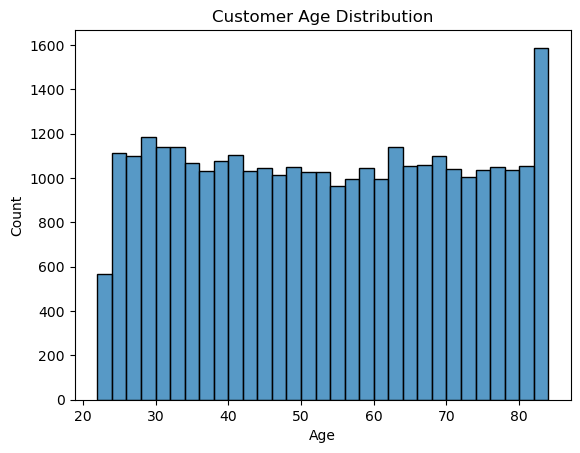

In [340]:
sns.histplot(data=cust_info[variable], palette=palette, bins=31)
plt.title('Customer ' + variable.capitalize() + ' Distribution')
plt.xlabel(variable.capitalize())
plt.ylabel('Count')
plt.show()

## `kids_home`

In [341]:
cust_info['kids_home'].head(10)

customer_id
3     1.0
4     1.0
5     0.0
7     0.0
8     0.0
9     1.0
10    2.0
11    1.0
12    0.0
14    1.0
Name: kids_home, dtype: float64

Distribution

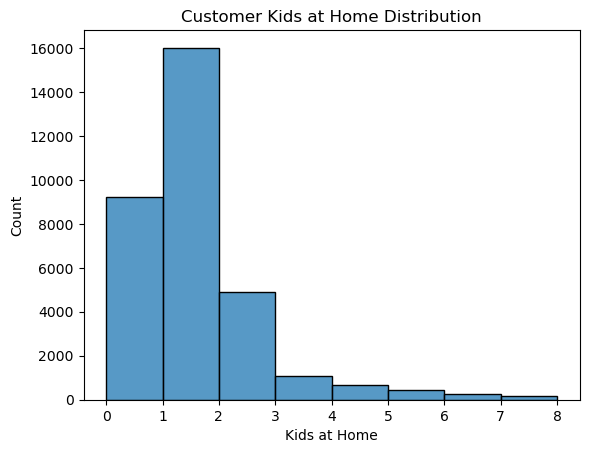

In [342]:
sns.histplot(data = cust_info['kids_home'], bins=8)
plt.title('Customer Kids at Home Distribution')
plt.xlabel('Kids at Home')
plt.ylabel('Count')
plt.show()

Outliers

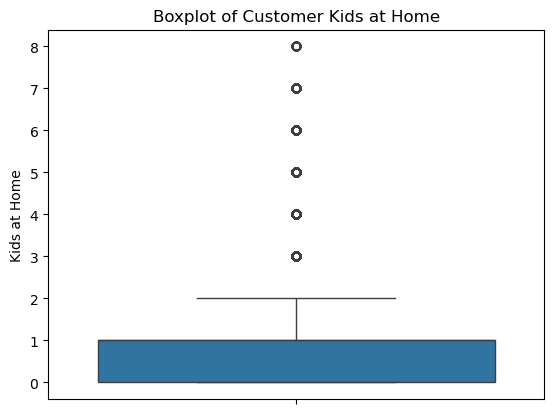

In [343]:
sns.boxplot(y=cust_info['kids_home'])
plt.title('Boxplot of Customer Kids at Home')
plt.ylabel('Kids at Home')
plt.show()

## `teens_home`

In [344]:
cust_info['teens_home'].head(10)

customer_id
3     1.0
4     0.0
5     0.0
7     0.0
8     0.0
9     1.0
10    1.0
11    1.0
12    0.0
14    0.0
Name: teens_home, dtype: float64

Distribution

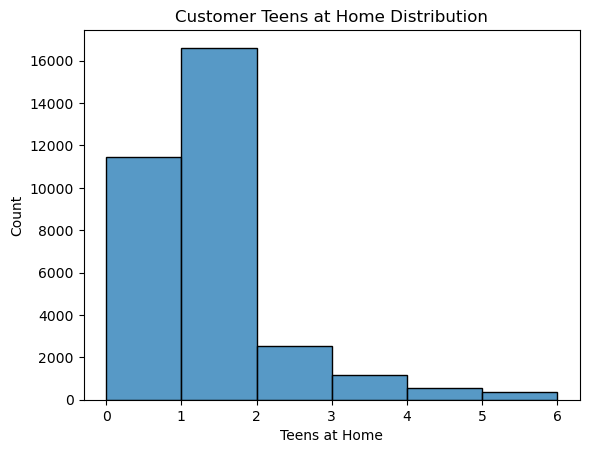

In [345]:
sns.histplot(data = cust_info['teens_home'], bins=6)
plt.title('Customer Teens at Home Distribution')
plt.xlabel('Teens at Home')
plt.ylabel('Count')
plt.show()

Outliers

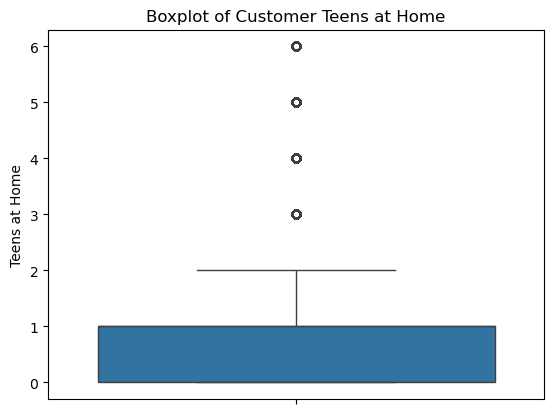

In [346]:
sns.boxplot(y=cust_info['teens_home'])
plt.title('Boxplot of Customer Teens at Home')
plt.ylabel('Teens at Home')
plt.show()

## `number_complaints`

In [347]:
cust_info['number_complaints'].head(10)

customer_id
3     1.0
4     0.0
5     NaN
7     2.0
8     3.0
9     1.0
10    0.0
11    1.0
12    0.0
14    1.0
Name: number_complaints, dtype: float64

Distribution

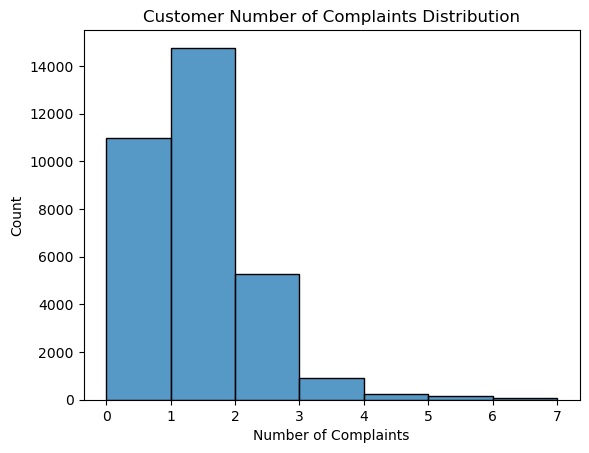

In [348]:
sns.histplot(data = cust_info['number_complaints'], bins=7)
plt.title('Customer Number of Complaints Distribution')
plt.xlabel('Number of Complaints')
plt.ylabel('Count')
plt.show()

Outliers

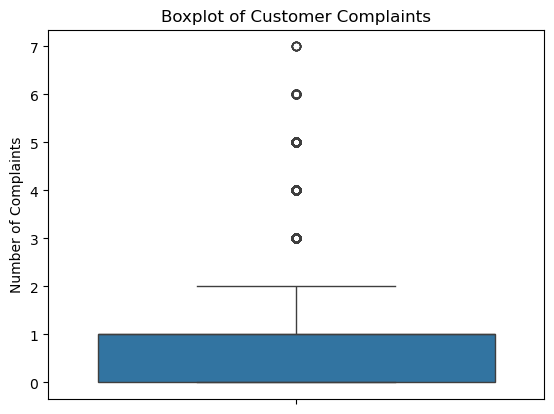

In [349]:
sns.boxplot(y=cust_info['number_complaints'])
plt.title('Boxplot of Customer Complaints')
plt.ylabel('Number of Complaints')
plt.show()

## `distinct_stores_visited`

In [350]:
cust_info['distinct_stores_visited'].head(10)

customer_id
3     3.0
4     2.0
5     2.0
7     1.0
8     1.0
9     6.0
10    1.0
11    6.0
12    2.0
14    3.0
Name: distinct_stores_visited, dtype: float64

Distribution

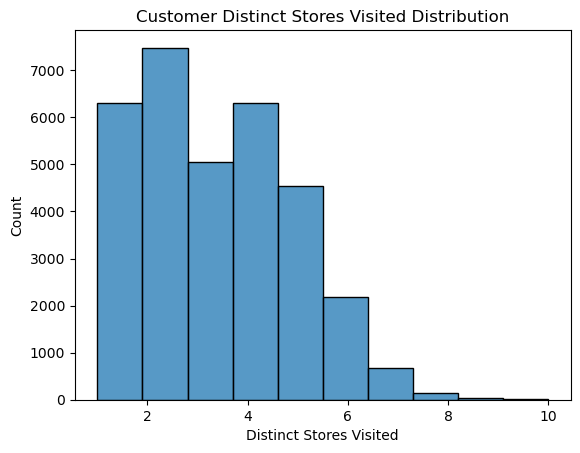

In [351]:
sns.histplot(data = cust_info['distinct_stores_visited'], bins=10)
plt.title('Customer Distinct Stores Visited Distribution')
plt.xlabel('Distinct Stores Visited')
plt.ylabel('Count')
plt.show()

Outliers

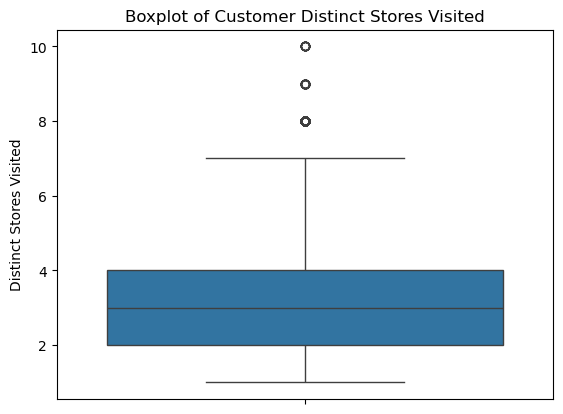

In [352]:
sns.boxplot(y=cust_info['distinct_stores_visited'])
plt.title('Boxplot of Customer Distinct Stores Visited')
plt.ylabel('Distinct Stores Visited')
plt.show()

## `lifetime_spend_groceries`

In [353]:
cust_info['lifetime_spend_groceries'].head(10)

customer_id
3     11731.0
4     13694.0
5     12407.0
7      7493.0
8      9187.0
9     16530.0
10    22240.0
11    29765.0
12     9281.0
14     7981.0
Name: lifetime_spend_groceries, dtype: float64

Distribution

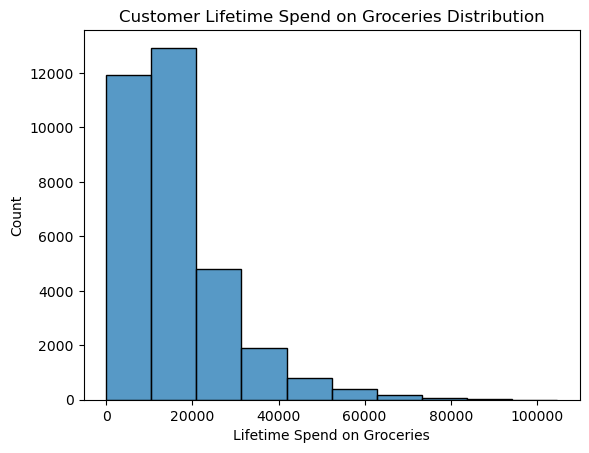

In [354]:
sns.histplot(data = cust_info['lifetime_spend_groceries'], bins=10)
plt.title('Customer Lifetime Spend on Groceries Distribution')
plt.xlabel('Lifetime Spend on Groceries')
plt.ylabel('Count')
plt.show()

Outliers

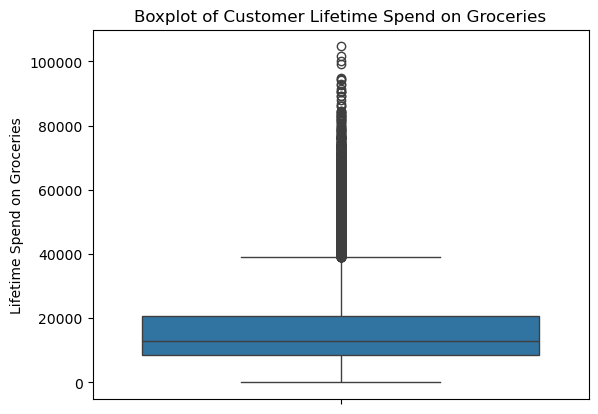

In [355]:
sns.boxplot(y=cust_info['lifetime_spend_groceries'])
plt.title('Boxplot of Customer Lifetime Spend on Groceries')
plt.ylabel('Lifetime Spend on Groceries')
plt.show()

## `lifetime_spend_electronics`

In [356]:
cust_info['lifetime_spend_electronics'].head(10)

customer_id
3      4553.0
4       963.0
5         0.0
7      1105.0
8     10841.0
9      1156.0
10        NaN
11     1543.0
12      254.0
14     2151.0
Name: lifetime_spend_electronics, dtype: float64

Distribution

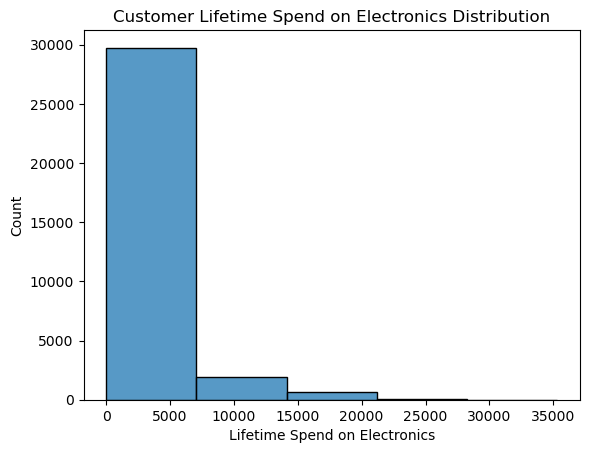

In [357]:
sns.histplot(data = cust_info['lifetime_spend_electronics'], bins=5)
plt.title('Customer Lifetime Spend on Electronics Distribution')
plt.xlabel('Lifetime Spend on Electronics')
plt.ylabel('Count')
plt.show()

Outliers

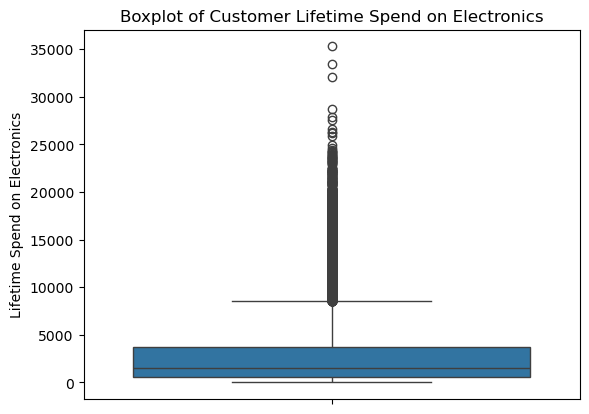

In [358]:
sns.boxplot(y=cust_info['lifetime_spend_electronics'])
plt.title('Boxplot of Customer Lifetime Spend on Electronics')
plt.ylabel('Lifetime Spend on Electronics')
plt.show()

## `typical_hour`

In [359]:
cust_info['typical_hour'].head(10)

customer_id
3      NaN
4      NaN
5     11.0
7     18.0
8     17.0
9      6.0
10     9.0
11    10.0
12    18.0
14    12.0
Name: typical_hour, dtype: float64

Distribution

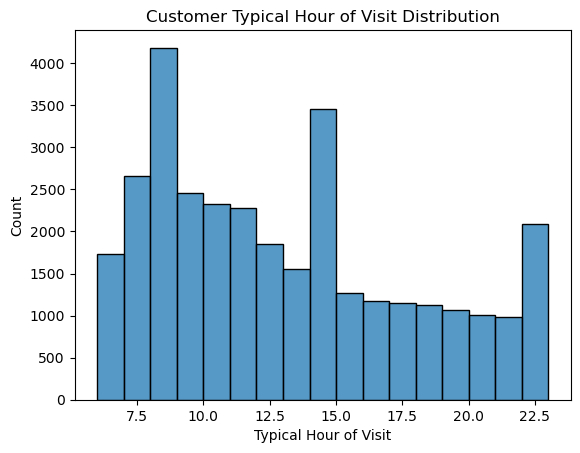

In [360]:
sns.histplot(data = cust_info['typical_hour'], bins=17)
plt.title('Customer Typical Hour of Visit Distribution')
plt.xlabel('Typical Hour of Visit')
plt.ylabel('Count')
plt.show()

Outliers

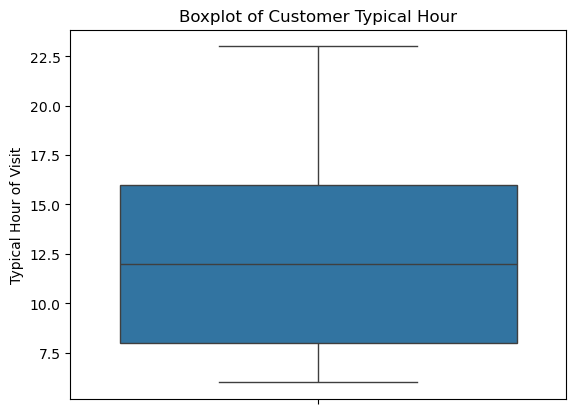

In [361]:
sns.boxplot(y=cust_info['typical_hour'])
plt.title('Boxplot of Customer Typical Hour')
plt.ylabel('Typical Hour of Visit')
plt.show()

## `lifetime_spend_vegetables`

In [362]:
cust_info['lifetime_spend_vegetables'].head(10)

customer_id
3      373.0
4     2012.0
5      555.0
7       84.0
8      380.0
9     1708.0
10    1284.0
11     190.0
12     125.0
14    1659.0
Name: lifetime_spend_vegetables, dtype: float64

Distribution

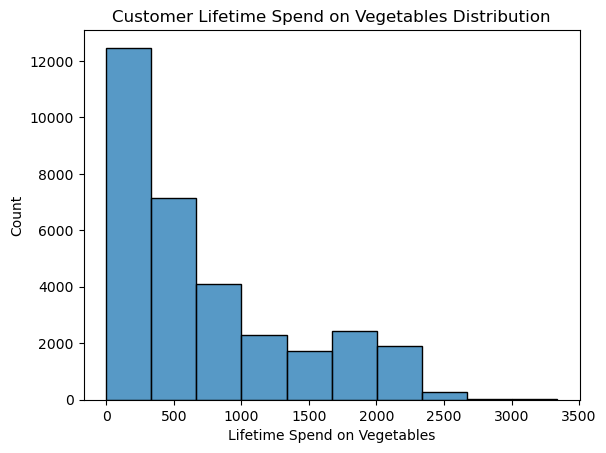

In [363]:
sns.histplot(data = cust_info['lifetime_spend_vegetables'], bins=10)
plt.title('Customer Lifetime Spend on Vegetables Distribution')
plt.xlabel('Lifetime Spend on Vegetables')
plt.ylabel('Count')
plt.show()

Outliers

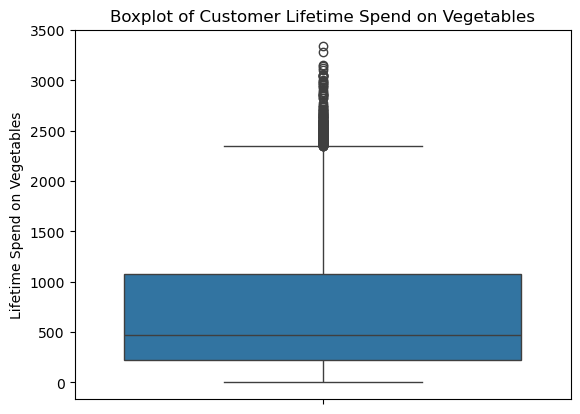

In [364]:
sns.boxplot(y=cust_info['lifetime_spend_vegetables'])
plt.title('Boxplot of Customer Lifetime Spend on Vegetables')
plt.ylabel('Lifetime Spend on Vegetables')
plt.show()

## `lifetime_spend_nonalcohol_drinks`

In [365]:
cust_info['lifetime_spend_nonalcohol_drinks'].head(10)

customer_id
3     323.0
4     533.0
5     101.0
7     757.0
8     592.0
9     406.0
10    538.0
11    411.0
12     60.0
14    799.0
Name: lifetime_spend_nonalcohol_drinks, dtype: float64

Distribution

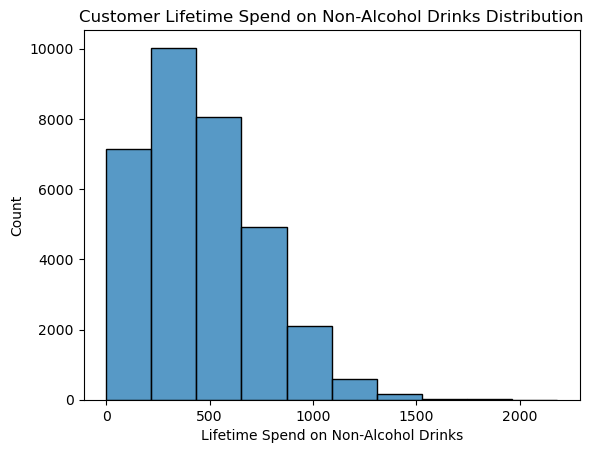

In [366]:
sns.histplot(data = cust_info['lifetime_spend_nonalcohol_drinks'], bins=10)
plt.title('Customer Lifetime Spend on Non-Alcohol Drinks Distribution')
plt.xlabel('Lifetime Spend on Non-Alcohol Drinks')
plt.ylabel('Count')
plt.show()

Outliers

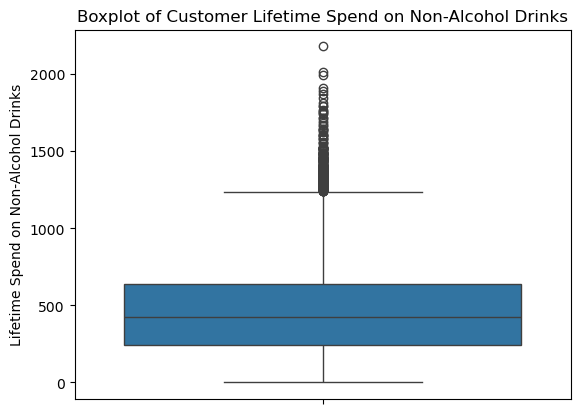

In [367]:
sns.boxplot(y=cust_info['lifetime_spend_nonalcohol_drinks'])
plt.title('Boxplot of Customer Lifetime Spend on Non-Alcohol Drinks')
plt.ylabel('Lifetime Spend on Non-Alcohol Drinks')
plt.show()

## `lifetime_spend_alcohol_drinks`

In [368]:
cust_info['lifetime_spend_alcohol_drinks'].head(10)

customer_id
3      177.0
4       95.0
5      118.0
7     1133.0
8      718.0
9      363.0
10    1970.0
11     641.0
12    1549.0
14     125.0
Name: lifetime_spend_alcohol_drinks, dtype: float64

Distribution

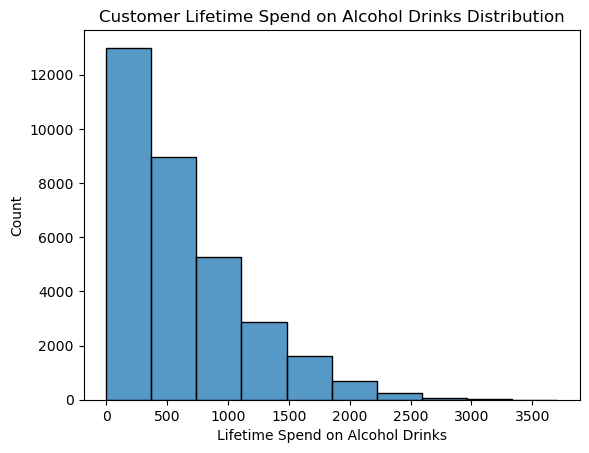

In [369]:
sns.histplot(data = cust_info['lifetime_spend_alcohol_drinks'], bins=10)
plt.title('Customer Lifetime Spend on Alcohol Drinks Distribution')
plt.xlabel('Lifetime Spend on Alcohol Drinks')
plt.ylabel('Count')
plt.show()

Outliers

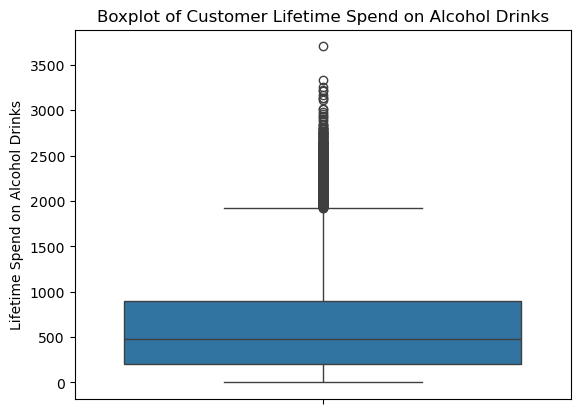

In [370]:
sns.boxplot(y=cust_info['lifetime_spend_alcohol_drinks'])
plt.title('Boxplot of Customer Lifetime Spend on Alcohol Drinks')
plt.ylabel('Lifetime Spend on Alcohol Drinks')
plt.show()

## `lifetime_spend_meat`

In [371]:
cust_info['lifetime_spend_meat'].head(10)

customer_id
3       28.0
4       43.0
5     1265.0
7      972.0
8     1068.0
9       27.0
10    1397.0
11     871.0
12     139.0
14     148.0
Name: lifetime_spend_meat, dtype: float64

Distribution

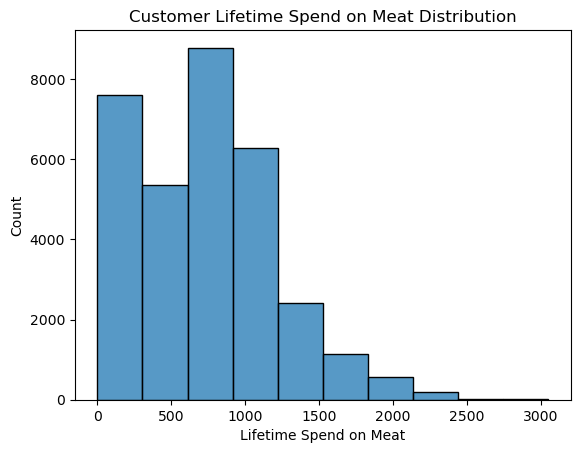

In [372]:
sns.histplot(data = cust_info['lifetime_spend_meat'], bins=10)
plt.title('Customer Lifetime Spend on Meat Distribution')
plt.xlabel('Lifetime Spend on Meat')
plt.ylabel('Count')
plt.show()

Outliers

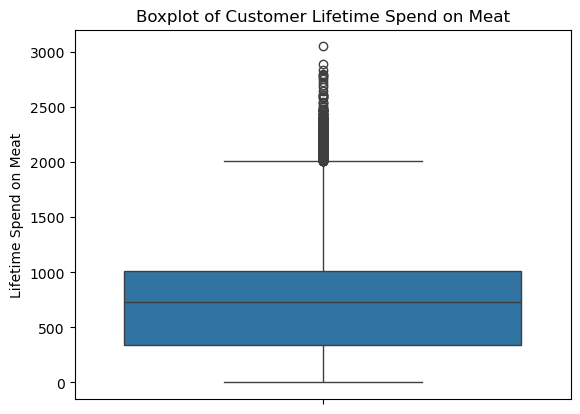

In [373]:
sns.boxplot(y=cust_info['lifetime_spend_meat'])
plt.title('Boxplot of Customer Lifetime Spend on Meat')
plt.ylabel('Lifetime Spend on Meat')
plt.show()

## `lifetime_spend_fish`

In [374]:
cust_info['lifetime_spend_fish'].head(10)

customer_id
3      213.0
4       15.0
5      273.0
7     1083.0
8     1015.0
9       76.0
10    1723.0
11     731.0
12     598.0
14      24.0
Name: lifetime_spend_fish, dtype: float64

Distribution

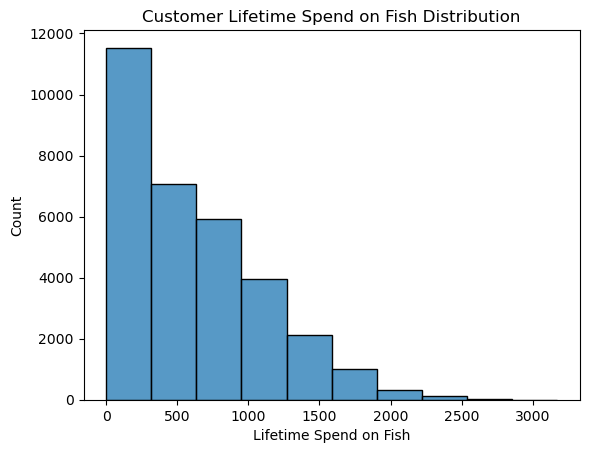

In [375]:
sns.histplot(data = cust_info['lifetime_spend_fish'], bins=10)
plt.title('Customer Lifetime Spend on Fish Distribution')
plt.xlabel('Lifetime Spend on Fish')
plt.ylabel('Count')
plt.show()

Outliers

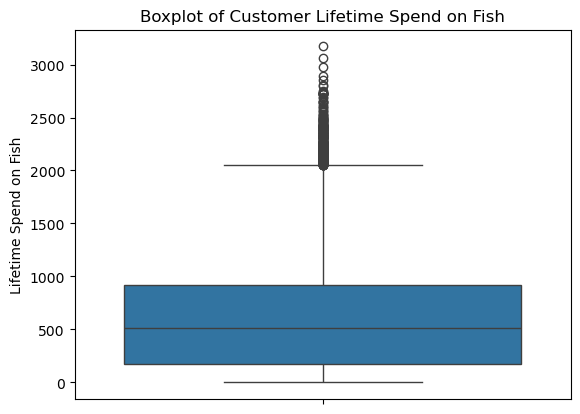

In [376]:
sns.boxplot(y=cust_info['lifetime_spend_fish'])
plt.title('Boxplot of Customer Lifetime Spend on Fish')
plt.ylabel('Lifetime Spend on Fish')
plt.show()

## `lifetime_spend_hygiene`

In [377]:
cust_info['lifetime_spend_hygiene'].head(10)

customer_id
3      552.0
4     1880.0
5      507.0
7      485.0
8      297.0
9      513.0
10     886.0
11    1240.0
12     673.0
14    1393.0
Name: lifetime_spend_hygiene, dtype: float64

Distribution

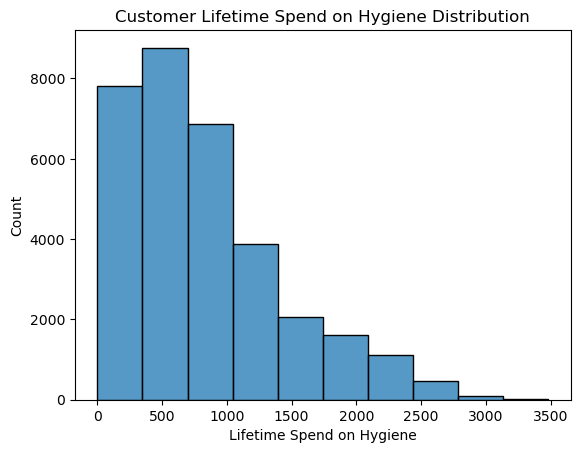

In [378]:
sns.histplot(data = cust_info['lifetime_spend_hygiene'], bins=10)
plt.title('Customer Lifetime Spend on Hygiene Distribution')
plt.xlabel('Lifetime Spend on Hygiene')
plt.ylabel('Count')
plt.show()

Outliers

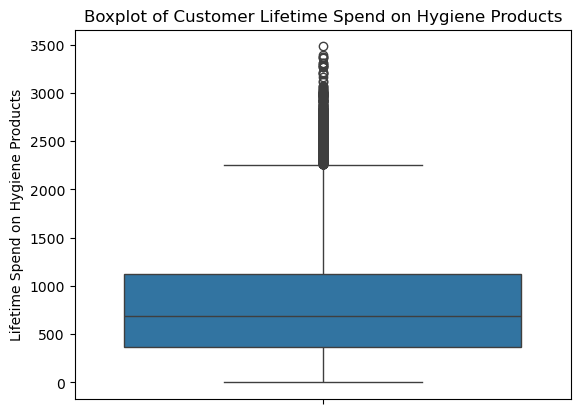

In [379]:
sns.boxplot(y=cust_info['lifetime_spend_hygiene'])
plt.title('Boxplot of Customer Lifetime Spend on Hygiene Products')
plt.ylabel('Lifetime Spend on Hygiene Products')
plt.show()

## `lifetime_spend_videogames`

In [380]:
cust_info['lifetime_spend_videogames'].head(10)

customer_id
3      256.0
4      333.0
5      101.0
7     1656.0
8     1258.0
9      225.0
10     203.0
11    1849.0
12      71.0
14     178.0
Name: lifetime_spend_videogames, dtype: float64

Distribution

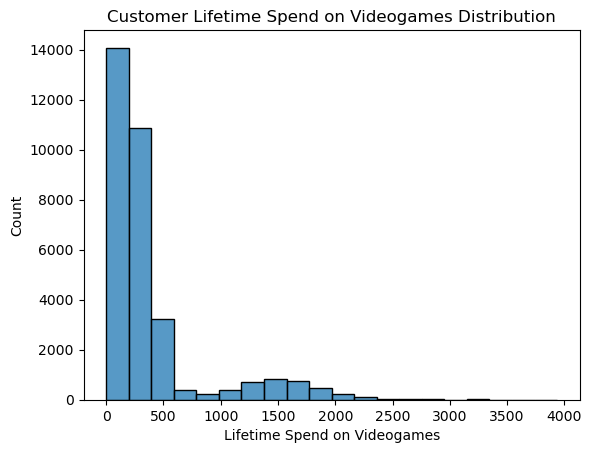

In [381]:
sns.histplot(data = cust_info['lifetime_spend_videogames'], bins=20)
plt.title('Customer Lifetime Spend on Videogames Distribution')
plt.xlabel('Lifetime Spend on Videogames')
plt.ylabel('Count')
plt.show()

Outliers

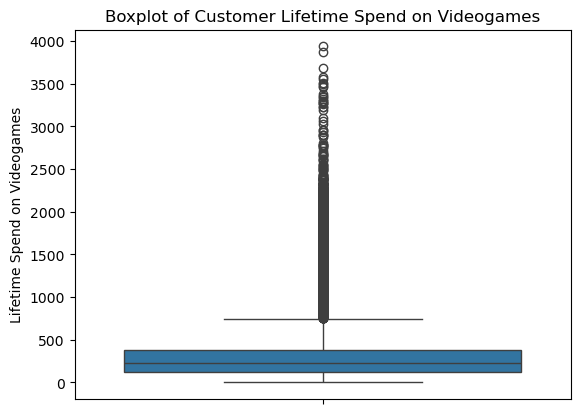

In [382]:
sns.boxplot(y=cust_info['lifetime_spend_videogames'])
plt.title('Boxplot of Customer Lifetime Spend on Videogames')
plt.ylabel('Lifetime Spend on Videogames')
plt.show()

## `lifetime_spend_petfood`

In [383]:
cust_info['lifetime_spend_petfood'].head(10)

customer_id
3     384.0
4     665.0
5     222.0
7     184.0
8     441.0
9       NaN
10    119.0
11    397.0
12     64.0
14     90.0
Name: lifetime_spend_petfood, dtype: float64

Distribution

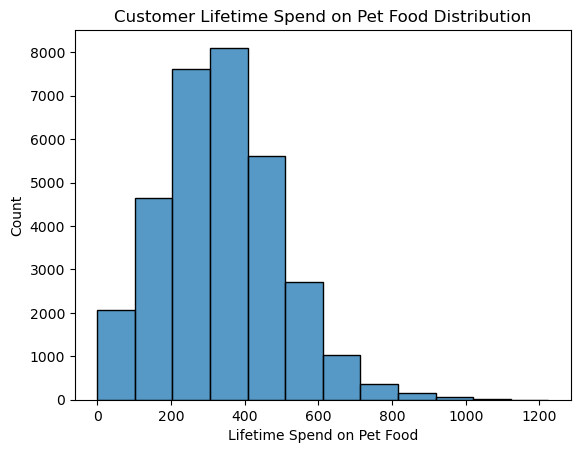

In [384]:
sns.histplot(data = cust_info['lifetime_spend_petfood'], bins=12)
plt.title('Customer Lifetime Spend on Pet Food Distribution')
plt.xlabel('Lifetime Spend on Pet Food')
plt.ylabel('Count')
plt.show()

Outliers

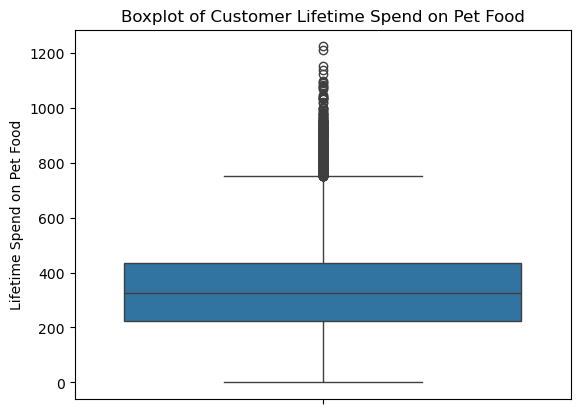

In [385]:
sns.boxplot(y=cust_info['lifetime_spend_petfood'])
plt.title('Boxplot of Customer Lifetime Spend on Pet Food')
plt.ylabel('Lifetime Spend on Pet Food')
plt.show()

## `lifetime_total_distinct_products`

In [386]:
cust_info['lifetime_total_distinct_products'].head(10)

customer_id
3     189.0
4     130.0
5      81.0
7      92.0
8       6.0
9      84.0
10    202.0
11    180.0
12     29.0
14     57.0
Name: lifetime_total_distinct_products, dtype: float64

Distribution

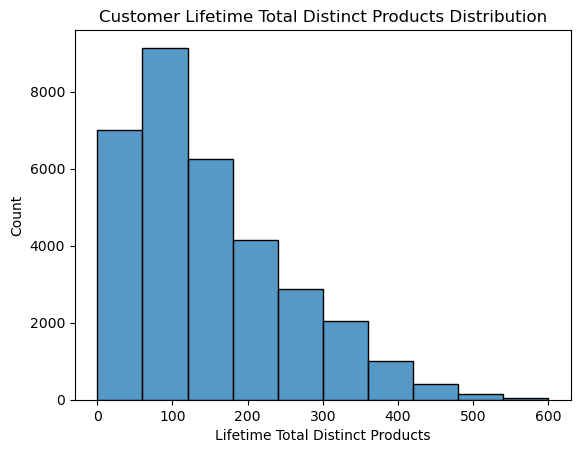

In [387]:
sns.histplot(data = cust_info['lifetime_total_distinct_products'], bins=10)
plt.title('Customer Lifetime Total Distinct Products Distribution')
plt.xlabel('Lifetime Total Distinct Products')
plt.ylabel('Count')
plt.show()

Outliers

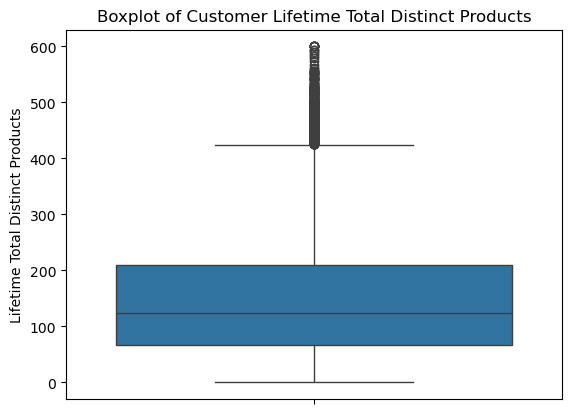

In [388]:
sns.boxplot(y=cust_info['lifetime_total_distinct_products'])
plt.title('Boxplot of Customer Lifetime Total Distinct Products')
plt.ylabel('Lifetime Total Distinct Products')
plt.show()

## `percentage_of_products_bought_promotion`

In [389]:
cust_info['percentage_of_products_bought_promotion'].head(10)

customer_id
3     0.631599
4     0.149890
5     0.069126
7     0.253609
8     0.186569
9     0.150646
10    0.275412
11    0.164251
12   -0.131176
14    0.197353
Name: percentage_of_products_bought_promotion, dtype: float64

Distribution

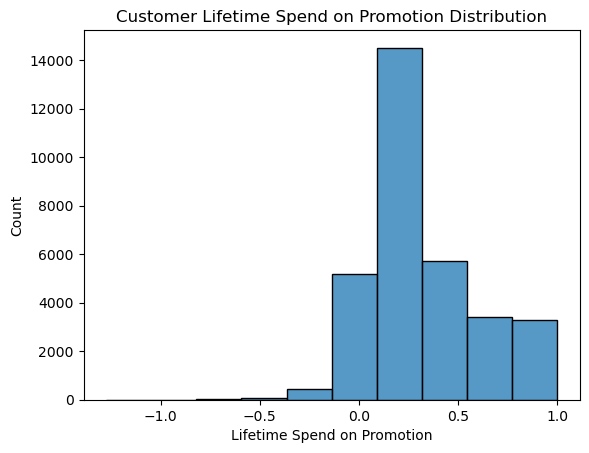

In [390]:
sns.histplot(data = cust_info['percentage_of_products_bought_promotion'], bins=10)
plt.title('Customer Lifetime Spend on Promotion Distribution')
plt.xlabel('Lifetime Spend on Promotion')
plt.ylabel('Count')
plt.show()

Outliers

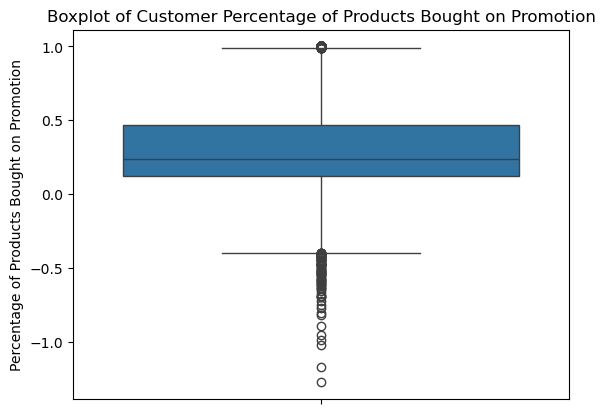

In [391]:
sns.boxplot(y=cust_info['percentage_of_products_bought_promotion'])
plt.title('Boxplot of Customer Percentage of Products Bought on Promotion')
plt.ylabel('Percentage of Products Bought on Promotion')
plt.show()

## `year_first_transaction`

In [392]:
cust_info['year_first_transaction'].head(10)

customer_id
3     2020.0
4     2013.0
5     2005.0
7     2021.0
8     2021.0
9     2011.0
10    2014.0
11    2017.0
12    2018.0
14    2017.0
Name: year_first_transaction, dtype: float64

Distribution

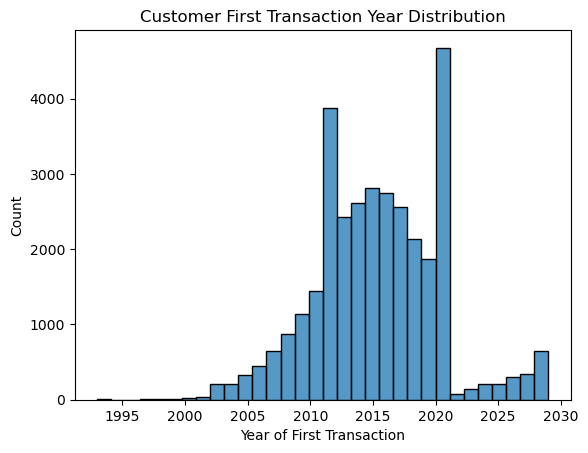

In [393]:
sns.histplot(data = cust_info['year_first_transaction'], bins=32)
plt.title('Customer First Transaction Year Distribution')
plt.xlabel('Year of First Transaction')
plt.ylabel('Count')
plt.show()

Outliers

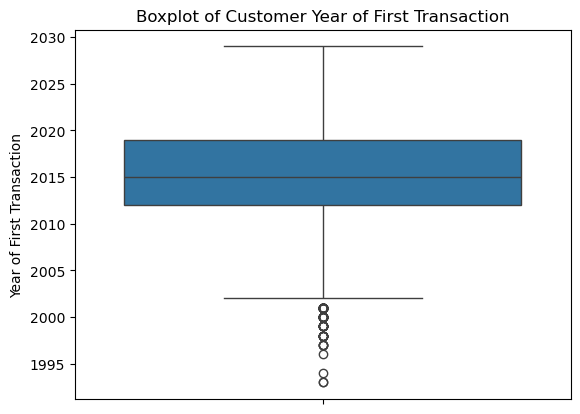

In [394]:
sns.boxplot(y=cust_info['year_first_transaction'])
plt.title('Boxplot of Customer Year of First Transaction')
plt.ylabel('Year of First Transaction')
plt.show()

## `loyalty_card_number`

In [395]:
cust_info['loyalty_card_number'].head(10)

customer_id
3     1.0
4     1.0
5     NaN
7     1.0
8     1.0
9     1.0
10    1.0
11    1.0
12    NaN
14    1.0
Name: loyalty_card_number, dtype: float64

Distribution

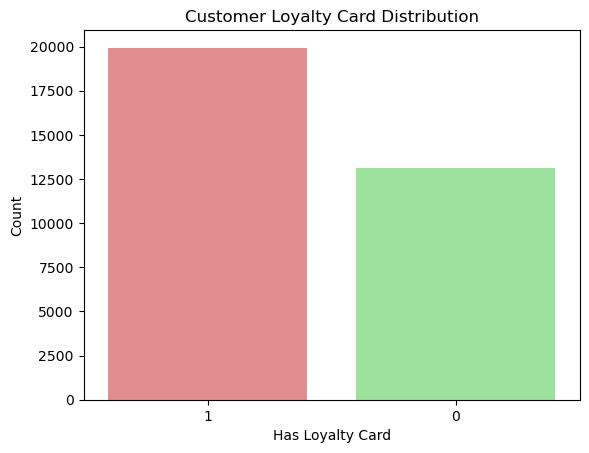

In [396]:
fill = cust_info['loyalty_card_number'].fillna(0).astype(int).astype(str)

palette2 = {'1': 'lightcoral', '0': 'lightgreen'}

sns.countplot(data=cust_info, x=fill, palette=palette2)
plt.title('Customer Loyalty Card Distribution')
plt.xlabel('Has Loyalty Card')
plt.ylabel('Count')
plt.show()

Outliers

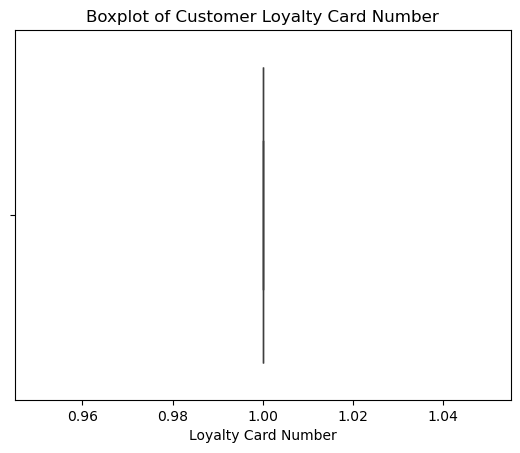

In [397]:
sns.boxplot(x=cust_info['loyalty_card_number'])
plt.title('Boxplot of Customer Loyalty Card Number')
plt.xlabel('Loyalty Card Number')
plt.show()

## `latitude` and `longitude`

In [398]:
cust_info[['latitude', 'longitude']].head(10)

,latitude,longitude
customer_id,,
3,38.794428,-9.215739
4,38.751711,-9.179611
5,38.780678,-9.160656
7,38.739548,-9.148679
8,38.733071,-9.188188
9,38.735577,-9.172423
10,38.730322,-9.144022
11,38.739328,-9.225047
12,38.748616,-9.167756


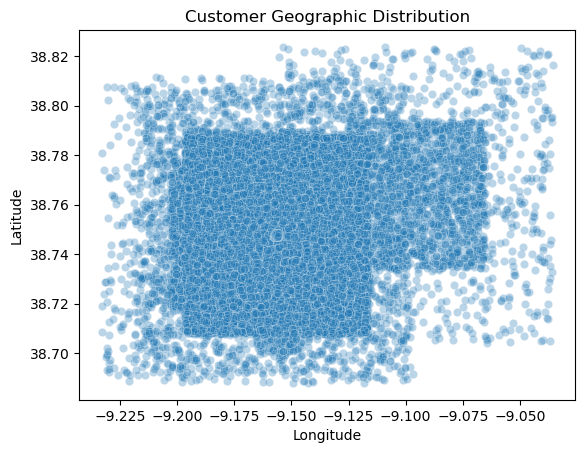

In [399]:
sns.scatterplot(data=cust_info, x='longitude', y='latitude', alpha=0.3)
plt.title('Customer Geographic Distribution')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

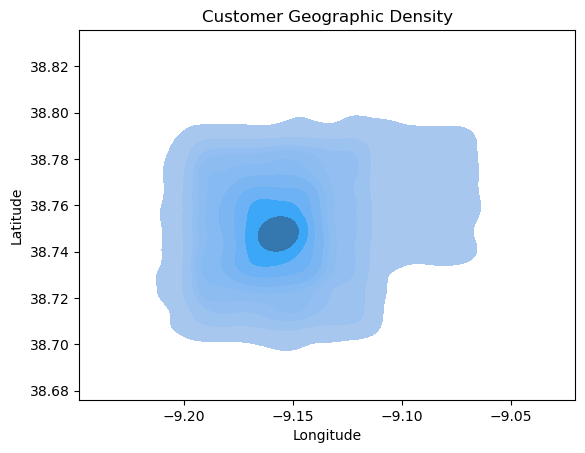

In [400]:
sns.kdeplot(data=cust_info, x='longitude', y='latitude', fill=True)
plt.title('Customer Geographic Density')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

# Correlation between variables

Numerical vs Numerical

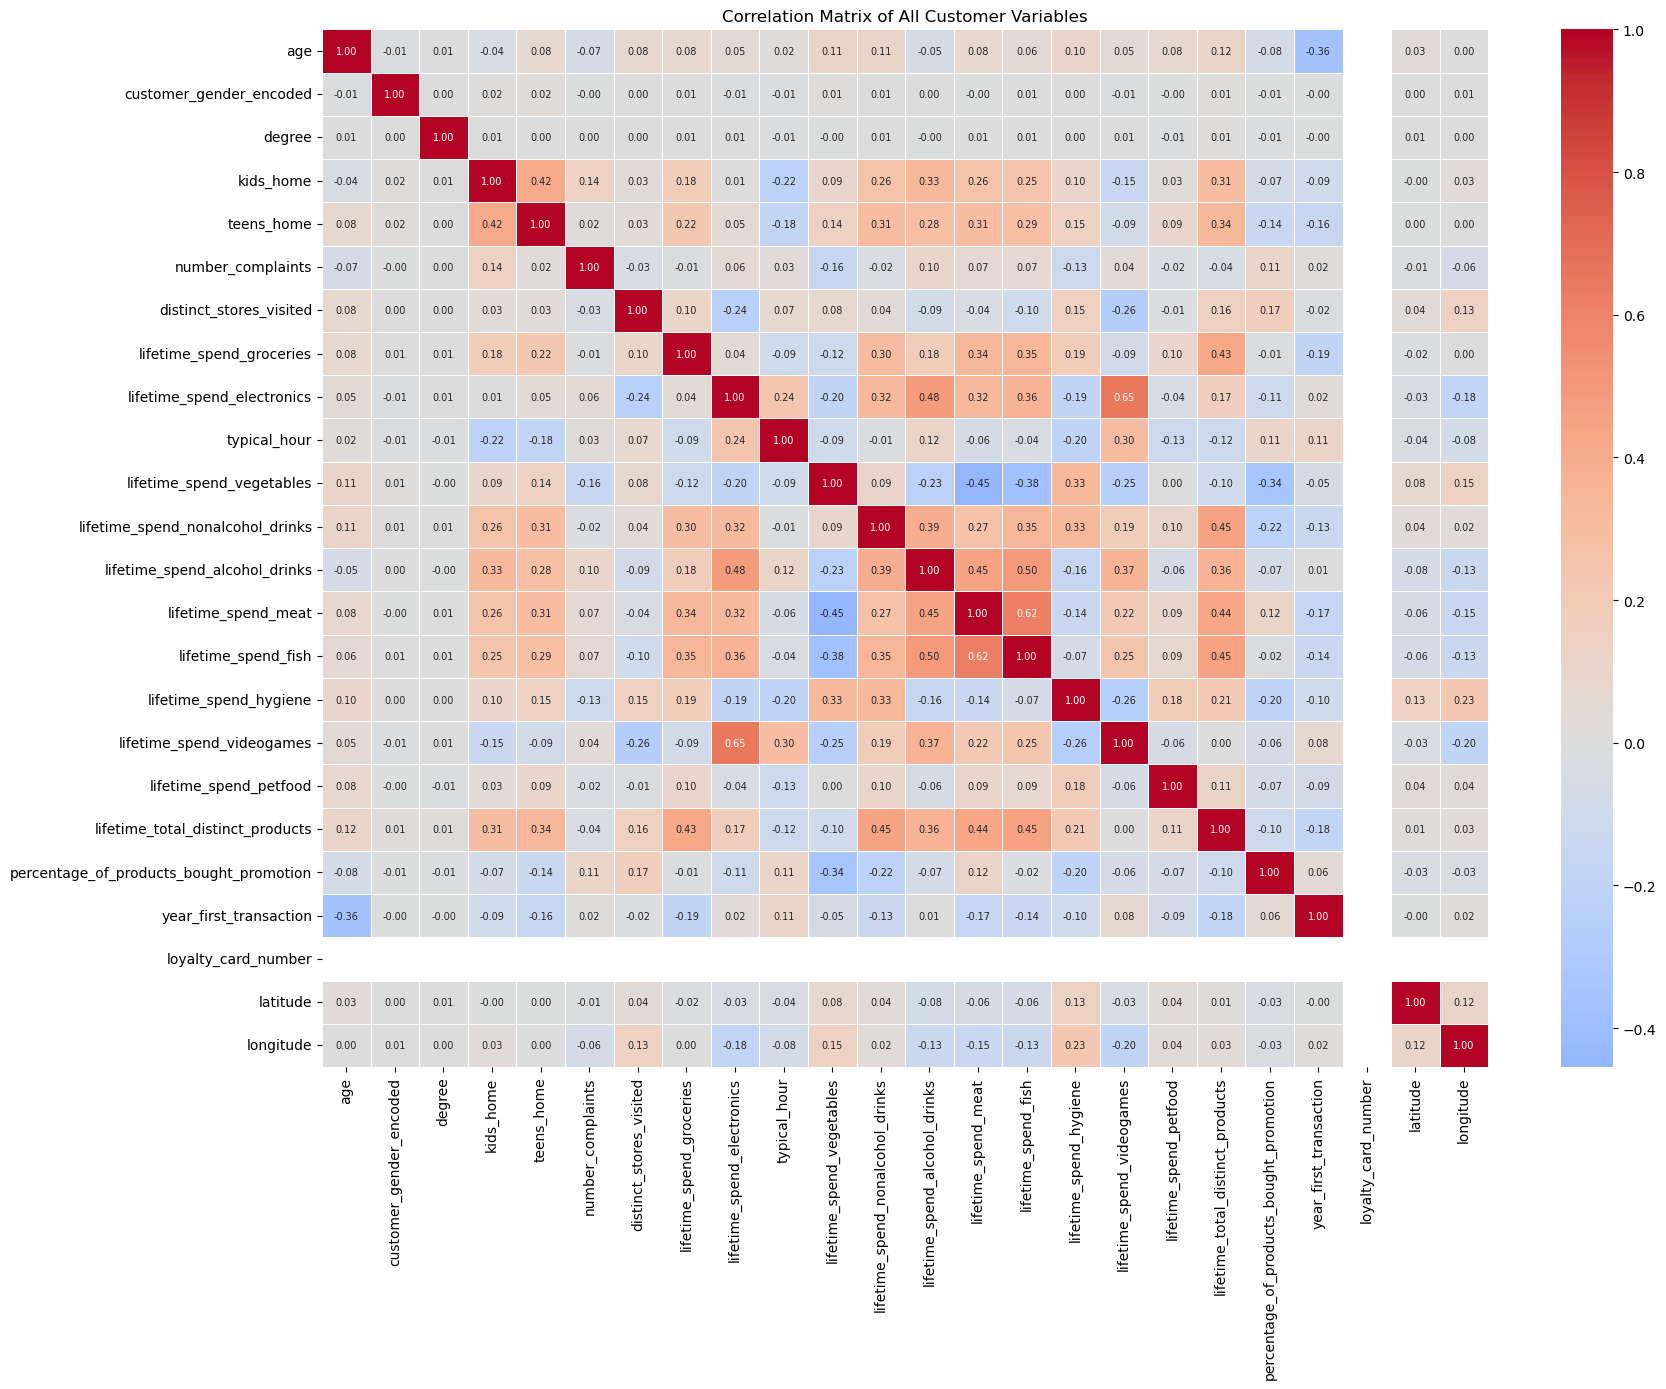

In [401]:
corr_df = cust_info.copy()

# Extract age from birthdate
corr_df['age'] = pd.Timestamp.now().year - pd.to_datetime(corr_df['customer_birthdate']).dt.year

# Extract degree from customer_name
corr_df['degree'] = corr_df['customer_name'].str.extract(r'(PhD|Master|Bachelor|Dr)', expand=False)

# Encode categoricals
le = LabelEncoder()
corr_df['customer_gender_encoded'] = le.fit_transform(corr_df['customer_gender'].astype(str))
corr_df['degree'] = le.fit_transform(corr_df['degree'].astype(str))

# Select final columns for correlation
corr_cols = [
    'age', 'customer_gender_encoded', 'degree', 'kids_home', 'teens_home',
    'number_complaints', 'distinct_stores_visited', 'lifetime_spend_groceries',
    'lifetime_spend_electronics', 'typical_hour', 'lifetime_spend_vegetables',
    'lifetime_spend_nonalcohol_drinks', 'lifetime_spend_alcohol_drinks',
    'lifetime_spend_meat', 'lifetime_spend_fish', 'lifetime_spend_hygiene',
    'lifetime_spend_videogames', 'lifetime_spend_petfood',
    'lifetime_total_distinct_products', 'percentage_of_products_bought_promotion',
    'year_first_transaction', 'loyalty_card_number', 'latitude', 'longitude'
]

corr_matrix = corr_df[corr_cols].corr()

plt.figure(figsize=(18, 14))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, annot_kws={'size': 7})
plt.title('Correlation Matrix of All Customer Variables')
plt.tight_layout()
plt.show()

In [402]:
cust_info.columns

Index(['customer_name', 'customer_gender', 'customer_birthdate', 'kids_home',
       'teens_home', 'number_complaints', 'distinct_stores_visited',
       'lifetime_spend_groceries', 'lifetime_spend_electronics',
       'typical_hour', 'lifetime_spend_vegetables',
       'lifetime_spend_nonalcohol_drinks', 'lifetime_spend_alcohol_drinks',
       'lifetime_spend_meat', 'lifetime_spend_fish', 'lifetime_spend_hygiene',
       'lifetime_spend_videogames', 'lifetime_spend_petfood',
       'lifetime_total_distinct_products',
       'percentage_of_products_bought_promotion', 'year_first_transaction',
       'loyalty_card_number', 'latitude', 'longitude', 'age'],
      dtype='object')

Categorical vs Numerical

In [403]:
categorical = [
    'customer_name',
    'customer_gender',
    'customer_birthdate',
    'year_first_transaction',
    'loyalty_card_number'
]

cust_info["has_loyalty_card"] = cust_info['loyalty_card_number'].fillna(0)
cust_info["has_loyalty_card"] = cust_info["has_loyalty_card"].astype(int)
categorical2 = [
    'customer_gender',
    'has_loyalty_card'
]
numerical = [
    'kids_home',
    'teens_home',
    'number_complaints',
    'distinct_stores_visited',
    'lifetime_spend_groceries',
    'lifetime_spend_electronics',
    'typical_hour',
    'lifetime_spend_vegetables',
    'lifetime_spend_nonalcohol_drinks',
    'lifetime_spend_alcohol_drinks',
    'lifetime_spend_meat',
    'lifetime_spend_fish',
    'lifetime_spend_hygiene',
    'lifetime_spend_videogames',
    'lifetime_spend_petfood',
    'lifetime_total_distinct_products',
    'percentage_of_products_bought_promotion',
    'latitude',
    'longitude'
]

In [404]:
# ANOVA

from scipy.stats import f_oneway

to_corr = []

for cat in categorical2:
    for num in numerical:
        groups = [
            cust_info[num][cust_info[cat] == val].dropna()
            for val in cust_info[cat].dropna().unique()
        ]

        if len(groups) < 2:
            continue

        f_stat, p_value = f_oneway(*groups)

        #print(f"{cat} vs {num}: F={f_stat:.3f}, p={p_value:.4f}")

        if p_value < 0.05:
            to_corr.append((cat, num))

if to_corr:
    print("\nSignificant associations found between:")
    for cat, num in to_corr:
        print(f"- {cat} and {num}")


Significant associations found between:
- customer_gender and kids_home
- customer_gender and teens_home
- customer_gender and lifetime_spend_vegetables
- customer_gender and lifetime_total_distinct_products
- has_loyalty_card and teens_home
- has_loyalty_card and number_complaints
- has_loyalty_card and distinct_stores_visited
- has_loyalty_card and lifetime_spend_groceries
- has_loyalty_card and lifetime_spend_electronics
- has_loyalty_card and typical_hour
- has_loyalty_card and lifetime_spend_vegetables
- has_loyalty_card and lifetime_spend_nonalcohol_drinks
- has_loyalty_card and lifetime_spend_alcohol_drinks
- has_loyalty_card and lifetime_spend_meat
- has_loyalty_card and lifetime_spend_fish
- has_loyalty_card and lifetime_spend_hygiene
- has_loyalty_card and lifetime_spend_videogames
- has_loyalty_card and lifetime_spend_petfood
- has_loyalty_card and lifetime_total_distinct_products
- has_loyalty_card and percentage_of_products_bought_promotion
- has_loyalty_card and longitud

Categorical Vs Categorical

In [405]:
# Chi squared

from scipy.stats import chi2_contingency
import pandas as pd

to_corr_cat = []

#for cat1 in categorical:
 #   for cat2 in categorical:
 #       if cat1 >= cat2:
 #           continue

  #      contingency_table = pd.crosstab(cust_info[cat1], cust_info[cat2])

  #      chi2, p, dof, expected = chi2_contingency(contingency_table)
#
   #     print(f"{cat1} vs {cat2}: chi2={chi2:.3f}, p={p:.4f}")
#
  #      if p < 0.05:
  #          to_corr_cat.append((cat1, cat2))
#
#if to_corr_cat:
  #  print("\nSignificant associations found between:")
  #  for cat1, cat2 in to_corr_cat:
   #     print(f"- {cat1} and {cat2}")